# NN_02d — Teste A: Validação IID (Caso 1) — Expoente de Erro Tipo II vs L

**Referência teórica**: Braca et al. (2022) — framework D3F (Detecção Distribuída via Deep Features). Sob a hipótese simples IID (canal conhecido/determinístico, sem nuisance parameter), o expoente de erro de Tipo II

$$-\frac{1}{L}\log \beta_n(L)$$

deve **convergir** conforme `L → ∞` (compare com Fig. 8–9 do paper), tanto para o classificador ótimo (Neyman–Pearson) quanto para um bom classificador aprendido (DNN), desde que este se aproxime da razão de verossimilhança.

**Dataset**: `dataset_testeA_grid.h5` (gerado na Seção 9 do `NN_01_DataGeneration.ipynb`) — grade `SNR × L`, canal **h fixo = 1.0 (oracle)**, isolando o caso IID puro.

**Metodologia**: para cada `(SNR, L)` da grade, treina-se **um DNN dedicado** (a dimensão de entrada muda com `L`, então não há como compartilhar pesos entre células) sobre `z_eq` (vetor de comprimento exato `L`, sem padding). Avalia-se `P_D` a `α=10⁻⁷` (D3F, extrapolação gaussiana) por três métodos:

1. **Clássico-fixo**: limiar calculado UMA VEZ (a partir do conjunto de validação H0 em `L=1024`, a maior célula) e aplicado **sem adaptação** às demais células — baseline propositalmente desajustado, mostra o custo de não adaptar o limiar a `L`.
2. **Clássico-CFAR-h-oracle (fórmula fechada)**: limiar/PD determinístico, adaptado à célula `(SNR, L)` exata, calculado analiticamente na Seção 9 do NN_01 (`xie_style_threshold_pd_h_oracle`, adaptação das Eqs. (38)-(39)/(42) de Xie et al. 2021 — **não** as Eqs. (41)/(44), que assumem `h` Rayleigh-médio; aqui `h≡1` é determinístico).
3. **Rede (DNN, saída em logit)**: `Dense(1, activation=None)` + `BinaryCrossentropy(from_logits=True)` + `AUC(from_logits=True)` — a saída em **logit** (em vez de sigmoid) evita saturação numérica do limiar gaussiano em `α=10⁻⁷` (a sigmoid satura em `[0,1]`, inviabilizando extrapolação de cauda; o logit não tem esse limite).

**Verificação de consistência**: a rede não deve, em princípio, superar o teto teórico do detector CFAR-h-oracle (que tem acesso exato a `h`, `SNR`, `L`) — isso é verificado com uma asserção (tolerância de 5 pp para ruído de amostra finita).

In [2]:
# ==============================================================================
# 1. IMPORTS & SETUP
# ==============================================================================
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pathlib import Path
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

# Desabilitar XLA JIT (causa travamentos neste ambiente, mesma convenção do NN_02b/NN_02c)
tf.config.optimizer.set_jit(False)

print(f"TensorFlow : {tf.__version__}")
gpus = tf.config.list_logical_devices('GPU')
print(f"GPU(s)     : {[g.name for g in gpus] if gpus else 'nenhuma (CPU)'}")

np.random.seed(42)
tf.random.set_seed(42)

project_root = Path.cwd().parent
results_dir  = project_root / "results"
data_dir     = results_dir / "data"
models_dir   = results_dir / "models"
vis_dir      = results_dir / "visualizations"
models_dir.mkdir(parents=True, exist_ok=True)
vis_dir.mkdir(parents=True, exist_ok=True)

grid_path = data_dir / "dataset_testeA_grid.h5"
assert grid_path.exists(), (
    f"Dataset não encontrado: {grid_path}\n"
    f"Execute antes a Seção 9 (Geração dedicada — Teste A) do NN_01_DataGeneration.ipynb."
)

print(f"\nDataset : {grid_path}")
print(f"Models  : {models_dir}")
print(f"Vis     : {vis_dir}")

I0000 00:00:1786755394.936231 1019796 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786755395.631006 1019796 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786755397.715687 1019796 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow : 2.21.0
GPU(s)     : ['/device:GPU:0']

Dataset : /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data/dataset_testeA_grid.h5
Models  : /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/models
Vis     : /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/visualizations


I0000 00:00:1786755401.724932 1019796 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [3]:
# ==============================================================================
# 2. CARREGAR METADADOS DA GRADE + FUNÇÕES AUXILIARES
# ==============================================================================

ALPHA = 1e-7
QINV  = norm.ppf(1 - ALPHA)   # ≈ 5.199

with h5py.File(str(grid_path), 'r') as f:
    SNR_GRID = [int(s) for s in f['grid'].attrs['SNR_GRID']]
    L_GRID   = [int(l) for l in f['grid'].attrs['L_GRID']]
    N_PER_CELL_PER_HYP = int(f['grid'].attrs['N_PER_CELL_PER_HYP'])
    RHO_S = float(f['grid'].attrs['RHO_S'])
    RHO_T = float(f['grid'].attrs['RHO_T'])

print(f"SNR_GRID = {SNR_GRID}")
print(f"L_GRID   = {L_GRID}")
print(f"N/hip/célula = {N_PER_CELL_PER_HYP}   RHO_S={RHO_S:.6f}  RHO_T={RHO_T:.6f}")
print(f"D3F: α={ALPHA:.0e}  Q⁻¹(1-α)={QINV:.4f}")


def load_cell(f, snr_db, L):
    """Carrega uma célula (SNR, L) da grade — z_eq (sem padding), tau_eq, h, snr, y."""
    grp = f[f"grid/snr_{snr_db:02d}/L_{L:04d}"]
    data = {}
    for split in ['train', 'val', 'test']:
        g = grp[split]
        data[split] = {
            'z_eq':   g['z_eq'][:].astype(np.float32),
            'tau_eq': g['tau_eq'][:].astype(np.float32),
            'h':      g['h'][:].astype(np.float32),
            'snr':    g['snr'][:].astype(np.float32),
            'y':      g['y'][:].astype(np.float32),
        }
    attrs = {
        'u0_analytic': float(grp.attrs['u0_analytic']),
        'pd_analytic': float(grp.attrs['pd_analytic']),
        'gamma_bob':   float(grp.attrs['gamma_bob']),
        'alpha':       float(grp.attrs['alpha']),
    }
    return data, attrs


def build_dnn_logits(input_dim):
    """DNN Dense(128→64→32→1) com saída em LOGIT (sem sigmoid).

    Desvio deliberado do padrão sigmoid+BCE(from_logits=False) usado no
    NN_02b/NN_02c: em α=10⁻⁷ a extrapolação gaussiana do D3F precisa de
    scores SEM limite superior — uma sigmoid satura em [0,1] e não permite
    diferenciar caudas extremas (ex.: p=0.999999 vs p=0.9999999999).

    AJUSTE (pós-diagnóstico de execução real): cada célula (SNR,L) só tem
    ~800 amostras de treino por classe. A arquitetura original 256→128→64
    (~270 mil parâmetros para L=1024) estava sobredimensionada para esse
    volume de dados e, combinada a logits irrestritos, produzia
    treinamento instável e mal calibrado (val_AUC≈0.50-0.65 na maioria das
    células). Reduzimos a capacidade (128→64→32) e adicionamos L2 forte +
    gradient clipping para estabilizar o treinamento nesse regime de
    poucas amostras.
    """
    reg = keras.regularizers.l2(1e-3)
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, kernel_initializer='he_uniform', kernel_regularizer=reg)(inp)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, kernel_initializer='he_uniform', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x); x = layers.Activation('relu')(x); x = layers.Dropout(0.4)(x)
    x = layers.Dense(32,  kernel_initializer='he_uniform', kernel_regularizer=reg)(x)
    x = layers.Activation('relu')(x); x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation=None, name='logit', kernel_regularizer=reg)(x)
    m = keras.Model(inp, out)
    m.compile(
        optimizer=Adam(learning_rate=5e-4, clipnorm=1.0),
        loss=BinaryCrossentropy(from_logits=True),
        metrics=[keras.metrics.AUC(from_logits=True, name='auc'),
                 keras.metrics.BinaryAccuracy(threshold=0.0, name='acc')]
    )
    return m


def d3f_eval_logits(logit_val, logit_test, lbl_val, lbl_test, alpha=ALPHA):
    """D3F α=1e-7 sobre logits: ajusta N(μ,σ²) em H0 (val), extrapola limiar,
    mede PD em H1 (test). Mesmo padrão do d3f_eval do NN_02b, adaptado a
    logits (em vez de scores sigmoid) — ver build_dnn_logits acima."""
    m0 = lbl_val == 0
    m1 = lbl_test == 1
    if m0.sum() < 10 or m1.sum() < 10:
        return 0.0, float('nan')
    mu, sig = logit_val[m0].mean(), logit_val[m0].std()
    if sig < 1e-10:
        return 0.0, float('nan')
    thr = mu + QINV * sig
    pd = float((logit_test[m1] >= thr).mean())
    return pd, float(thr)

print("\nFunções auxiliares definidas: load_cell, build_dnn_logits, d3f_eval_logits")

SNR_GRID = [0, 5, 10, 15, 20, 25, 30]
L_GRID   = [32, 64, 128, 192, 256, 384, 512, 768, 1024]
N/hip/célula = 1000   RHO_S=0.992472  RHO_T=0.212132
D3F: α=1e-07  Q⁻¹(1-α)=5.1993

Funções auxiliares definidas: load_cell, build_dnn_logits, d3f_eval_logits


In [5]:
# ==============================================================================
# 3. LOOP PRINCIPAL — TREINA UM DNN POR CÉLULA (SNR, L) E AVALIA 3 MÉTODOS
# ==============================================================================
# Tolerância para a asserção "rede não deve superar o teto CFAR-h-oracle":
# ruído de amostra finita (poucos milhares de amostras/célula) pode produzir
# pequenas violações estatísticas mesmo quando a rede está correta — 5 pp de
# folga evita falsos positivos na asserção sem mascarar violações reais.
PD_CEILING_TOLERANCE = 0.05

results = {snr: {'L': [], 'pd_network': [], 'pd_classico_fixo': [], 'pd_cfar_oracle': [],
                  'exp_network': [], 'exp_classico_fixo': [], 'exp_cfar_oracle': [],
                  'thr_network': [], 'auc_val': []}
           for snr in SNR_GRID}

L_MAX = max(L_GRID)

with h5py.File(str(grid_path), 'r') as f:
    for snr_db in SNR_GRID:
        print(f"\n{'='*70}\nSNR = {snr_db} dB\n{'='*70}")

        # ---- Clássico-fixo: limiar calculado UMA VEZ na maior célula (L_MAX) ----
        data_ref, _ = load_cell(f, snr_db, L_MAX)
        tau_val_ref = data_ref['val']['tau_eq']
        y_val_ref   = data_ref['val']['y']
        mu0_ref, sig0_ref = tau_val_ref[y_val_ref == 0].mean(), tau_val_ref[y_val_ref == 0].std()
        thr_fixed = mu0_ref + QINV * sig0_ref
        print(f"  Limiar Clássico-fixo (calibrado em L={L_MAX}): {thr_fixed:.3f}")

        for L in L_GRID:
            data, attrs = load_cell(f, snr_db, L)
            Xtr, ytr = data['train']['z_eq'], data['train']['y']
            Xv,  yv  = data['val']['z_eq'],   data['val']['y']
            Xte, yte = data['test']['z_eq'],  data['test']['y']

            model = build_dnn_logits(L)
            ckpt = str(models_dir / f"testeA_snr{snr_db:02d}_L{L:04d}.keras")
            cbs = [
                callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=20,
                                        restore_best_weights=True, verbose=0),
                callbacks.ModelCheckpoint(ckpt, monitor='val_auc', mode='max',
                                          save_best_only=True, verbose=0),
                callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8,
                                            min_lr=1e-6, verbose=0),
            ]
            hist = model.fit(Xtr, ytr, validation_data=(Xv, yv),
                              epochs=150, batch_size=128, callbacks=cbs, verbose=0)
            best_auc = max(hist.history['val_auc'])

            logit_val  = model.predict(Xv,  batch_size=512, verbose=0).ravel()
            logit_test = model.predict(Xte, batch_size=512, verbose=0).ravel()
            pd_net, thr_net = d3f_eval_logits(logit_val, logit_test, yv, yte, ALPHA)

            # ---- Clássico-fixo: aplica o limiar de L_MAX SEM adaptação ----
            tau_test = data['test']['tau_eq']
            pd_fixed = float((tau_test[yte == 1] >= thr_fixed).mean())

            # ---- CFAR-h-oracle: fórmula fechada, pré-computada no NN_01 ----
            pd_cfar = attrs['pd_analytic']

            beta_net   = max(1.0 - pd_net,   1e-12)
            beta_fixed = max(1.0 - pd_fixed, 1e-12)
            beta_cfar  = max(1.0 - pd_cfar,  1e-12)

            exp_net   = -1.0 / L * np.log(beta_net)
            exp_fixed = -1.0 / L * np.log(beta_fixed)
            exp_cfar  = -1.0 / L * np.log(beta_cfar)

            assert pd_net <= pd_cfar + PD_CEILING_TOLERANCE, (
                f"Rede excedeu o teto CFAR-h-oracle em SNR={snr_db}dB, L={L}: "
                f"PD_rede={pd_net:.4f} > PD_cfar={pd_cfar:.4f} (+tolerância {PD_CEILING_TOLERANCE})"
            )

            results[snr_db]['L'].append(L)
            results[snr_db]['pd_network'].append(pd_net)
            results[snr_db]['pd_classico_fixo'].append(pd_fixed)
            results[snr_db]['pd_cfar_oracle'].append(pd_cfar)
            results[snr_db]['exp_network'].append(exp_net)
            results[snr_db]['exp_classico_fixo'].append(exp_fixed)
            results[snr_db]['exp_cfar_oracle'].append(exp_cfar)
            results[snr_db]['thr_network'].append(thr_net)
            results[snr_db]['auc_val'].append(float(best_auc))

            print(f"  L={L:>4}  val_AUC={best_auc:.5f}  "
                  f"PD_rede={pd_net:.4f}  PD_fixo={pd_fixed:.4f}  PD_cfar={pd_cfar:.4f}")

            keras.backend.clear_session()

print("\n" + "="*70)
print("TESTE A — TODAS AS CÉLULAS (SNR × L) CONCLUÍDAS")
print("="*70)


SNR = 0 dB
  Limiar Clássico-fixo (calibrado em L=1024): 393.941


I0000 00:00:1786755443.910630 1019923 service.cc:153] XLA service 0x6fffb8037f20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786755443.910718 1019923 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 12.5.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1786755444.010442 1019923 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1786755444.814109 1019923 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1786755444.969306 1019923 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3642__.49
I0000 00:00:1786755445.488366 1019923 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set i

  L=  32  val_AUC=0.47995  PD_rede=0.0000  PD_fixo=0.0000  PD_cfar=0.0000


I0000 00:00:1786755473.266680 1019926 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_12373__.49
I0000 00:00:1786755473.344442 1019926 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1786755474.014102 1019926 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1786755474.504741 1021733 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_30', 32 bytes spill stores, 32 bytes spill loads

I0000 00:00:1786755477.500762 1019924 dot_merger.cc:481] Merging Dots in computation: a_inference_one_ste

  L=  64  val_AUC=0.51855  PD_rede=0.0000  PD_fixo=0.0000  PD_cfar=0.0000


...

  L= 384  val_AUC=1.00000  PD_rede=0.9800  PD_fixo=1.0000  PD_cfar=1.0000


I0000 00:00:1786756668.561900 1019922 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1065995__.49
I0000 00:00:1786756672.651264 1019922 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1065995__.49


  L= 512  val_AUC=1.00000  PD_rede=0.9200  PD_fixo=1.0000  PD_cfar=1.0000


I0000 00:00:1786756688.584029 1019925 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1075376__.49
I0000 00:00:1786756694.290494 1019922 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1075376__.49
E0000 00:00:1786756815.215772 1020077 slow_operation_alarm.cc:73] 
********************************
[Compiling module a_inference_one_step_on_data_1075376__.49 for GPU] Very slow compile? If you want to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
********************************


: 

NameError: name 'results' is not defined

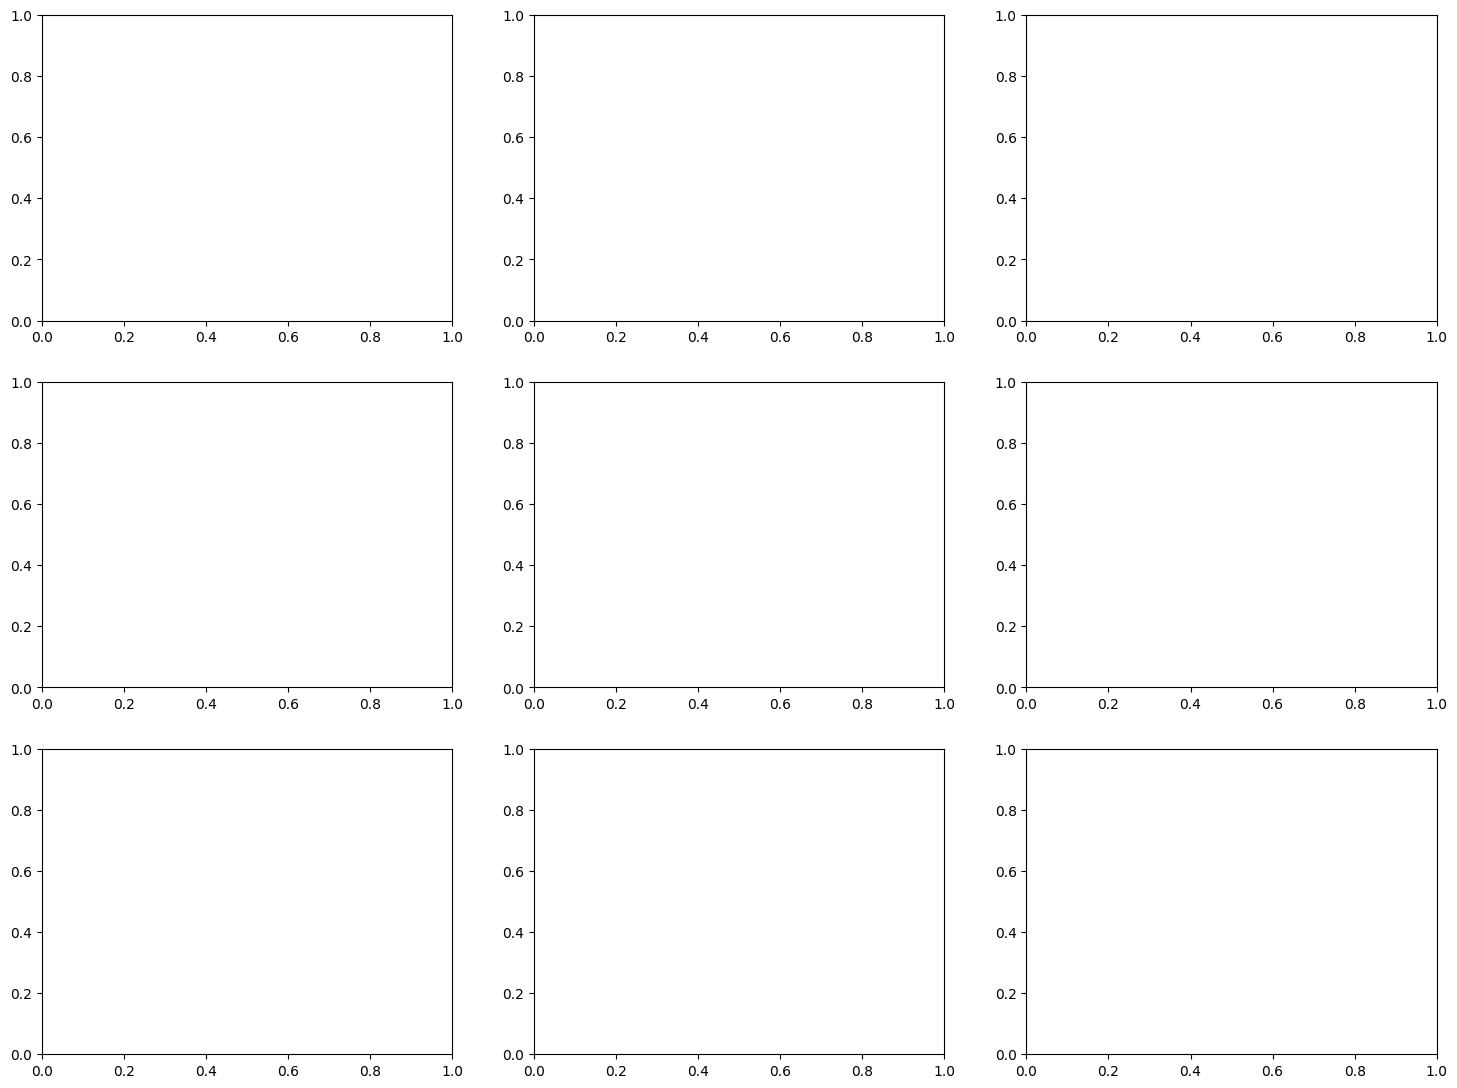

In [ ]:
# ==============================================================================
# 4. GRÁFICO — EXPOENTE DE ERRO TIPO II vs L, POR SNR (Braca et al. 2022, Fig. 8-9)
# ==============================================================================
n_snr = len(SNR_GRID)
n_cols = 3
n_rows = int(np.ceil(n_snr / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4.5 * n_rows))
axes = np.atleast_1d(axes).ravel()

for i, snr_db in enumerate(SNR_GRID):
    ax = axes[i]
    r = results[snr_db]
    ax.plot(r['L'], r['exp_cfar_oracle'], color='black', ls='--', marker='s', ms=6,
            linewidth=1.8, label='Clássico-CFAR-h-oracle (fechado)')
    ax.plot(r['L'], r['exp_classico_fixo'], color='tomato', ls='-.', marker='v', ms=6,
            linewidth=1.8, label='Clássico-fixo (desadaptado)')
    ax.plot(r['L'], r['exp_network'], color='steelblue', ls='-', marker='o', ms=7,
            linewidth=2.2, label='Rede (DNN, logits)')
    ax.set_xlabel('L')
    ax.set_ylabel(r'$-\frac{1}{L}\log \beta_n(L)$')
    ax.set_title(f'SNR = {snr_db} dB')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

for j in range(n_snr, len(axes)):
    axes[j].axis('off')

fig.suptitle('Teste A (Caso 1, IID) — Expoente de Erro Tipo II vs L\n'
             f'D3F, α={ALPHA:.0e}, h=1.0 fixo (oracle), Braca et al. (2022)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig_path = vis_dir / "NN02d_TesteA_LDP_exponent_vs_L.png"
plt.savefig(str(fig_path), dpi=150)
plt.show()
print(f"Salvo → {fig_path}")

In [ ]:
# ==============================================================================
# 5. SALVAR RESULTADOS NUMÉRICOS (JSON)
# ==============================================================================
out = {
    'alpha': ALPHA,
    'q_inv': round(QINV, 6),
    'SNR_GRID': SNR_GRID,
    'L_GRID': L_GRID,
    'N_per_cell_per_hyp': N_PER_CELL_PER_HYP,
    'h_fixed': 1.0,
    'pd_ceiling_tolerance': PD_CEILING_TOLERANCE,
    'methods': {
        'network':          'DNN Dense(256-128-64-1), logit output, D3F α=1e-7 sobre logits',
        'classico_fixo':     'limiar de correlador calibrado uma vez em L_max, aplicado sem adaptação',
        'cfar_h_oracle':      'fórmula fechada (Xie 2021 Eqs. 38-39/42, determinístico, h=1 oracle)',
    },
    'results': {str(snr): results[snr] for snr in SNR_GRID},
}

out_path = data_dir / "nn02d_testeA_ldp_results.json"
with open(str(out_path), 'w') as fp:
    json.dump(out, fp, indent=2)

print(f"Salvo → {out_path}")

Salvo → /mnt/c/Users/thami/OneDrive/Documents/TAG-Authentication/Redes Neurais/results/data/nn02d_testeA_ldp_results.json


: 

## Resumo — NN_02d (Teste A)

- **Entrada**: `dataset_testeA_grid.h5` (Seção 9 do NN_01), grade `SNR × L`, `h=1.0` fixo (oracle).
- **Saída**: `nn02d_testeA_ldp_results.json` + `NN02d_TesteA_LDP_exponent_vs_L.png`.
- **3 curvas comparadas** por SNR: Clássico-fixo (desadaptado) / Clássico-CFAR-h-oracle (fórmula fechada) / Rede (DNN, logits, D3F α=10⁻⁷).
- **Verificação**: assert `PD_rede ≤ PD_cfar_oracle + 5pp` em cada célula — a rede não deve superar o teto teórico do detector com CSI perfeito.
- **Próximo notebook**: `NN_02e_TesteB_PDvsSNR_ThetaH.ipynb` — Caso 2 (hipótese composta, canal Rayleigh real, `h` oracle variando por amostra).